In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# 1. Data Generators
# ----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "split_data/train",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "split_data/val",
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 13726 images belonging to 5 classes.
Found 2722 images belonging to 5 classes.


In [5]:
# ----------------------------
# 2. Base Model
# ----------------------------
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False


In [6]:
# ----------------------------
# 3. Custom Model (IMPORTANT)
# ----------------------------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

# FINAL MODEL
model = Model(inputs=base_model.input, outputs=output)


In [7]:
# 4. Compile
# ----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# 5. Early Stopping
# ----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [13]:
# ----------------------------
# 6. Train (Phase 1)
# ----------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)


# ----------------------------
# 7. Fine-Tuning
# ----------------------------
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 718s 829ms/step - accuracy: 0.8613 - loss: 0.3943 - val_accuracy: 0.9342 - val_loss: 0.1885
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 533s 621ms/step - accuracy: 0.9249 - loss: 0.2193 - val_accuracy: 0.9225 - val_loss: 0.2236
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 574s 669ms/step - accuracy: 0.9328 - loss: 0.1856 - val_accuracy: 0.9511 - val_loss: 0.1412
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 571s 666ms/step - accuracy: 0.9377 - loss: 0.1704 - val_accuracy: 0.9607 - val_loss: 0.1082
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 541s 631ms/step - accuracy: 0.9417 - loss: 0.1571 - val_accuracy: 0.9563 - val_loss: 0.1263
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 518s 604ms/step - accuracy: 0.9452 - loss: 0.1507 - val_accuracy: 0.9658 - val_loss: 0.0941
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 521s 607ms/step - accuracy: 0.9448 - loss: 0.1465 - val_accuracy: 0.9596 - val_loss: 0.1053
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 515s 600ms/step - accuracy: 0.9504 -

In [14]:
# 8. Save Model
# ----------------------------
model.save("mobilenetv2.h5")

In [9]:
# 9. Prediction
# ----------------------------
val_data.reset()

predictions = model.predict(val_data)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = val_data.classes

class_labels = list(val_data.class_indices.keys())

171/171 ━━━━━━━━━━━━━━━━━━━━ 66s 375ms/step


In [10]:
# ----------------------------
# 10. Evaluation
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)


Classification Report:

              precision    recall  f1-score   support

       Boron       0.12      0.51      0.19       366
     Healthy       0.24      0.08      0.12       463
      Kalium       0.00      0.00      0.00       777
          Mg       0.09      0.00      0.01       734
    nitrogen       0.13      0.33      0.19       382

    accuracy                           0.13      2722
   macro avg       0.12      0.19      0.10      2722
weighted avg       0.10      0.13      0.08      2722


Confusion Matrix:

[[187  22   0   0 157]
 [291  38   0   1 133]
 [441  27   0   4 305]
 [470  40   0   3 221]
 [201  30   0  24 127]]


C:\Users\admin\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## 1. Predict SINGLE IMAGE

In [16]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load trained model
model = tf.keras.models.load_model("mobilenetv2.h5")

# Class labels (IMPORTANT - same order as training)
class_labels = list(train_data.class_indices.keys())

# Load image
img_path = r"split_data\test\nitrogen\nitrogen (458).jpg"   # 🔁 change your image path
img = image.load_img(img_path, target_size=(224, 224))

# Preprocess
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
pred = model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
confidence = np.max(pred)

# Output
print("Predicted Class:", class_labels[pred_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: nitrogen
Confidence: 1.0


## 2. Predict MULTIPLE IMAGES (Folder)

In [ ]:
# import os

# folder_path = "test_images/"   # 🔁 your folder

# for img_name in os.listdir(folder_path):
#     img_path = os.path.join(folder_path, img_name)

#     img = image.load_img(img_path, target_size=(224, 224))
#     img_array = image.img_to_array(img) / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     pred = model.predict(img_array)
#     pred_class = np.argmax(pred, axis=1)[0]
#     confidence = np.max(pred)

#     print(f"{img_name} → {class_labels[pred_class]} ({confidence:.2f})")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'test_images/'

## Fix labels permanently

In [17]:
import json
with open("labels.json", "w") as f:
    json.dump(train_data.class_indices, f)

## Load labels during prediction

In [18]:
import json

with open("labels.json", "r") as f:
    class_indices = json.load(f)

class_labels = list(class_indices.keys())

## Show image + prediction

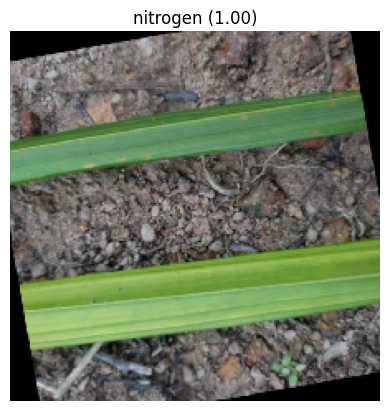

In [19]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{class_labels[pred_class]} ({confidence:.2f})")
plt.axis('off')
plt.show()

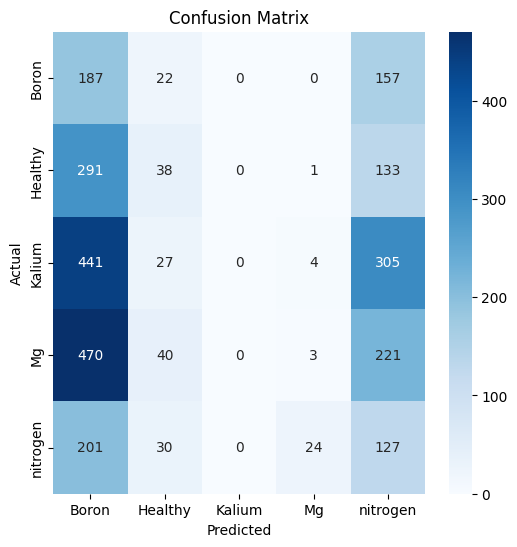

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()